In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr, mannwhitneyu, ttest_ind, shapiro, levene
import statsmodels.api as sm

In [45]:
df = pd.read_csv("merged_cosmetic_product_dataset (3).csv")

In [46]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (293, 13)

Columns:
['brand', 'product_name', 'loves_count', 'rating', 'label', 'price', 'dry', 'normal', 'oily', 'sensitive', 'log_price', 'log_loves_count', 'CF']


,brand,product_name,loves_count,rating,label,price,dry,normal,oily,sensitive,log_price,log_loves_count,CF
0,belif,The True Cream Aqua Bomb,265050,4.49205,Moisturizer,38.0,0,1,1,0,3.663562,12.487678,0
1,First Aid Beauty,Ultra Repair Cream Intense Hydration,300432,4.56000,Moisturizer,38.0,1,1,1,1,3.663562,12.612980,1
2,Shiseido,Bio-Performance Advanced Super Revitalizing Cream,22311,4.56675,Moisturizer,85.0,0,0,0,0,4.454347,10.012880,0
3,fresh,Black Tea Firming Overnight Mask,73168,4.11845,Moisturizer,96.0,1,1,0,0,4.574711,11.200527,0
4,belif,The True Cream Moisturizing Bomb,151868,4.58155,Moisturizer,38.0,1,1,0,0,3.663562,11.930774,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            293 non-null    object 
 1   product_name     293 non-null    object 
 2   loves_count      293 non-null    int64  
 3   rating           293 non-null    float64
 4   label            293 non-null    object 
 5   price            293 non-null    float64
 6   dry              293 non-null    int64  
 7   normal           293 non-null    int64  
 8   oily             293 non-null    int64  
 9   sensitive        293 non-null    int64  
 10  log_price        293 non-null    float64
 11  log_loves_count  293 non-null    float64
 12  CF               293 non-null    int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 29.9+ KB


In [48]:
numeric_cols = [
    "loves_count",
    "rating",
    "price",
    "dry",
    "normal",
    "oily",
    "sensitive",
    "log_price",
    "log_loves_count",
    "CF"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [49]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
brand              0
product_name       0
loves_count        0
rating             0
label              0
price              0
dry                0
normal             0
oily               0
sensitive          0
log_price          0
log_loves_count    0
CF                 0
dtype: int64


In [50]:
duplicate_count = df.duplicated(subset=["brand", "product_name"]).sum()

print("Duplicate product count:", duplicate_count)

Duplicate product count: 0


In [51]:
print(df["CF"].value_counts())

print("\nPercentage:")
print(df["CF"].value_counts(normalize=True) * 100)

CF
0    194
1     99
Name: count, dtype: int64

Percentage:
CF
0    66.211604
1    33.788396
Name: proportion, dtype: float64


In the merged dataset, 99 products belong to brands identified as cruelty-free, while 194 products belong to brands not identified as cruelty-free in the cruelty-free brand list. This corresponds to approximately 33.8% cruelty-free and 66.2% non-cruelty-free/unknown products.

In [52]:
sns.set(style="whitegrid")

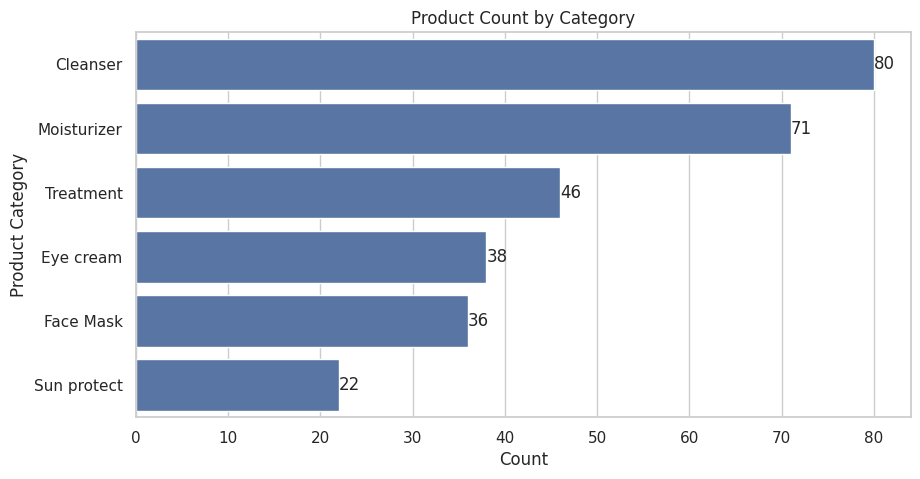

In [53]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    y="label",
    order=df["label"].value_counts().index
)

plt.title("Product Count by Category")
plt.xlabel("Count")
plt.ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

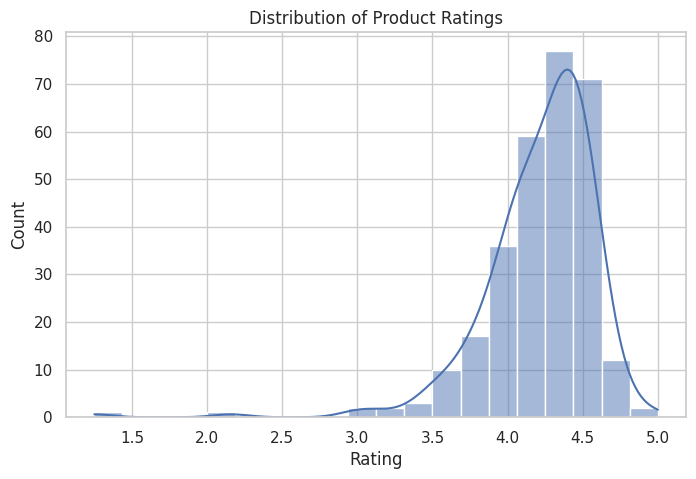

In [54]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="rating", bins=20, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Overview: The histogram shows that product ratings are not evenly distributed. Most products have high ratings, especially between 4.0 and 4.6. Very low ratings are rare, which suggests that the rating variable is concentrated in a narrow high-rating range. Because of this limited variation, it may be harder to detect strong relationships between rating and other variables such as price, loves_count, or cruelty-free status.



In [55]:
print("Rating summary statistics:")
print(df["rating"].describe())

print("\nRating quantiles:")
print(df["rating"].quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

Rating summary statistics:
count    293.000000
mean       4.215560
std        0.381056
min        1.250000
25%        4.063100
50%        4.294400
75%        4.465050
max        5.000000
Name: rating, dtype: float64

Rating quantiles:
0.25    4.06310
0.50    4.29440
0.75    4.46505
0.90    4.56675
0.95    4.61374
Name: rating, dtype: float64


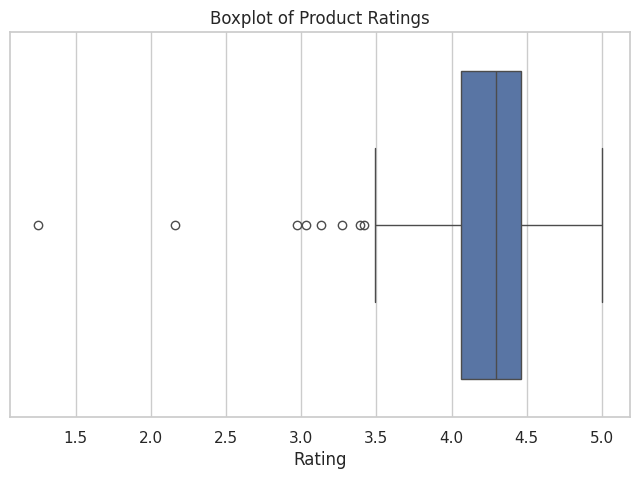

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="rating")
plt.title("Boxplot of Product Ratings")
plt.xlabel("Rating")
plt.show()

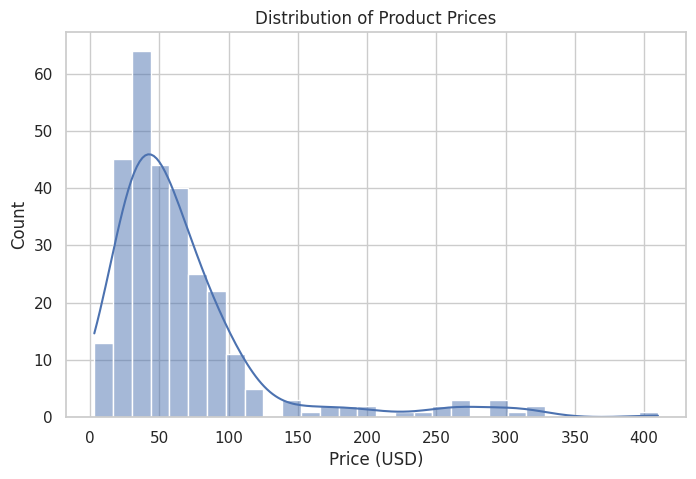

In [57]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="price", bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

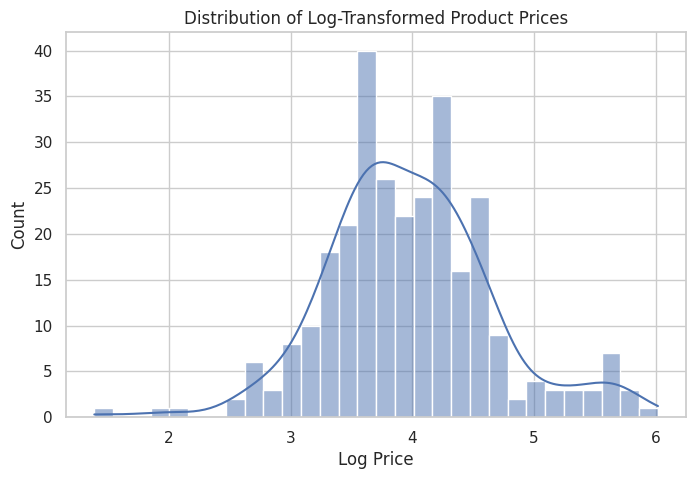

In [58]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="log_price", bins=30, kde=True)
plt.title("Distribution of Log-Transformed Product Prices")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.show()

Overview: The original price distribution is strongly right-skewed. Most products are concentrated in the lower and middle price range, especially around 20–80 USD. However, there are a few very expensive products with prices above 150 USD, and some products even reach around 300–400 USD. These high-priced products create a long right tail in the distribution.

Because of this skewness, the original price variable may be affected by extreme values. Therefore, a log-transformed price variable was also examined. After applying the log transformation, the distribution becomes more balanced and closer to a normal-like shape. This makes log_price more suitable for correlation analysis and hypothesis testing than the raw price variable.

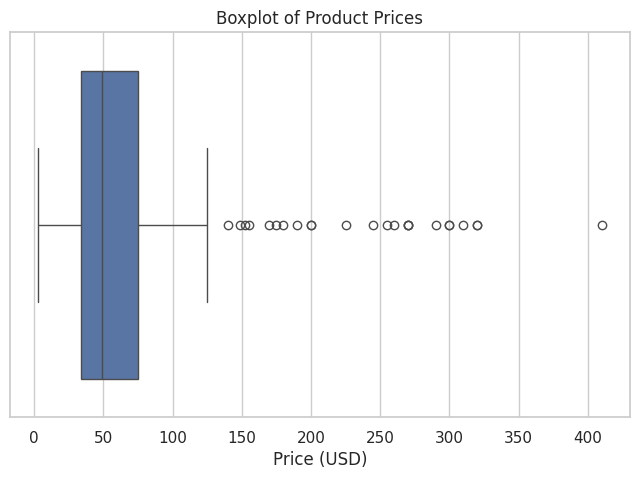

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="price")
plt.title("Boxplot of Product Prices")
plt.xlabel("Price (USD)")
plt.show()

Overview: The boxplot shows that most product prices are concentrated in the lower and middle price range.
The median price is around 40–50 USD, and most products appear to be below approximately 70 USD.
However, there are several high-price outliers above 120 USD, with some products reaching above 250–300 USD.
This confirms that the price variable is right-skewed and affected by expensive outliers.

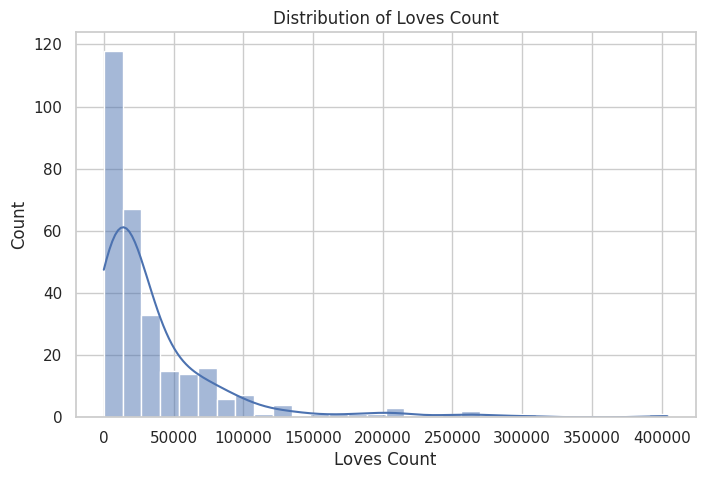

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="loves_count", bins=30, kde=True)
plt.title("Distribution of Loves Count")
plt.xlabel("Loves Count")
plt.ylabel("Count")
plt.show()

Overview: The distribution of loves_count is strongly right-skewed. Most products have relatively low loves_count values, while only a small number of products receive very high numbers of loves. Some products reach above 200,000 and even close to 400,000 loves, which creates a long right tail in the distribution. This shows that product popularity is not evenly distributed across the dataset; a few products are much more popular than the majority.

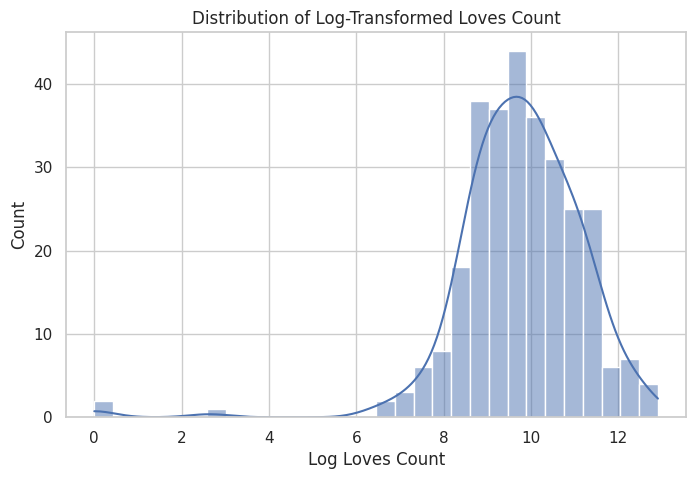

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="log_loves_count", bins=30, kde=True)
plt.title("Distribution of Log-Transformed Loves Count")
plt.xlabel("Log Loves Count")
plt.ylabel("Count")
plt.show()

Overview: After applying the log transformation, the loves_count distribution becomes much more balanced compared to the original distribution. In the raw loves_count graph, the data was highly right-skewed because a few products had extremely high love counts. However, in this log-transformed graph, most values are concentrated between approximately 8 and 11, and the distribution looks closer to a normal-like shape. This means log_loves_count is more suitable for later correlation and hypothesis testing because it reduces the influence of extreme popularity outliers.

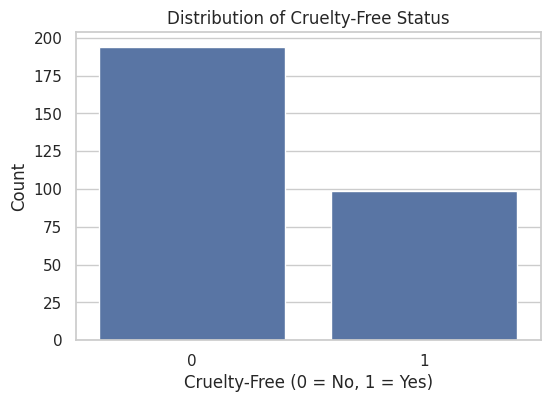

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="CF")
plt.title("Distribution of Cruelty-Free Status")
plt.xlabel("Cruelty-Free (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

The distribution of cruelty-free status is imbalanced, with a much larger number of non-cruelty-free products compared to cruelty-free products. This imbalance should be considered when comparing ratings, prices, or loves_count between the two groups, because the cruelty-free group has a much smaller sample size.

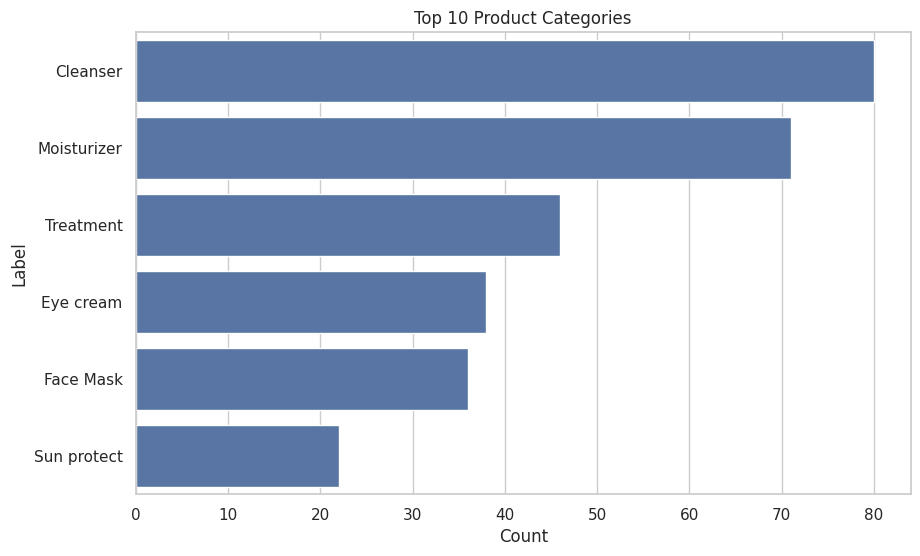

In [63]:
top_labels = df["label"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="label", order=top_labels)
plt.title("Top 10 Product Categories")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()

The product category distribution is not completely balanced. Cleanser and Moisturizer are the dominant categories in the dataset, while Sun protect has the lowest count among the displayed categories. This imbalance should be considered in later analyses because categories with more products may have a stronger influence on overall results.

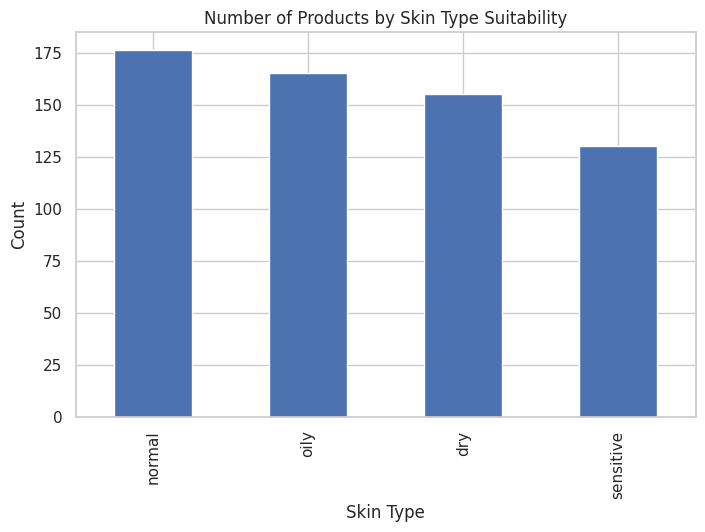

In [64]:
skin_counts = {
    "dry": df["dry"].sum(),
    "normal": df["normal"].sum(),
    "oily": df["oily"].sum(),
    "sensitive": df["sensitive"].sum()
}

skin_counts = pd.Series(skin_counts)

plt.figure(figsize=(8,5))
skin_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Number of Products by Skin Type Suitability")
plt.xlabel("Skin Type")
plt.ylabel("Count")
plt.show()

Overview: This chart shows the number of products labeled as suitable for each skin type. Since a product can be suitable for more than one skin type, these categories are not mutually exclusive and the counts do not need to add up to the total number of products. Normal skin has the highest number of suitable products, followed by oily and dry skin. Sensitive skin has the lowest count, suggesting that fewer products in this dataset are labeled as suitable for sensitive skin.

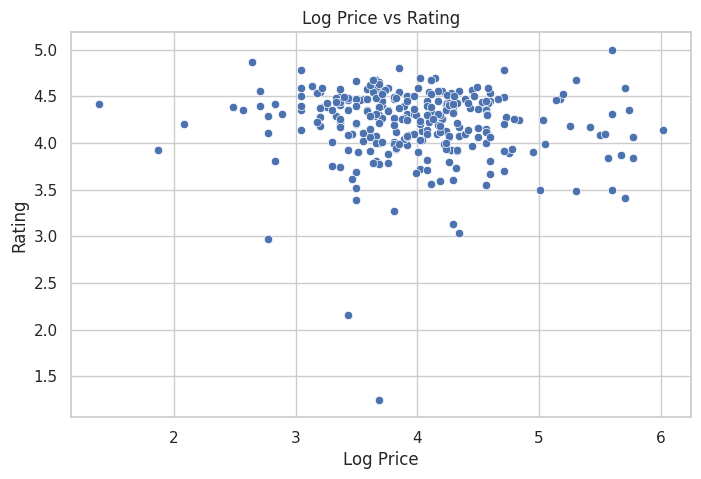

In [65]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="log_price", y="rating")
plt.title("Log Price vs Rating")
plt.xlabel("Log Price")
plt.ylabel("Rating")
plt.show()

In [66]:
spearman_corr, spearman_p = spearmanr(df["log_price"], df["rating"])
print("\nSpearman correlation between log_price and rating:")
print("rho =", spearman_corr)
print("p-value =", spearman_p)


Spearman correlation between log_price and rating:
rho = -0.1425632323860023
p-value = 0.014592160072993316


"The Spearman correlation between log_price and rating is weak and negative (rho = -0.143, p = 0.015). Although the result is statistically significant, the effect size is very small, suggesting that higher-priced products do not necessarily receive higher ratings. Price alone is not a meaningful predictor of customer satisfaction in this dataset."

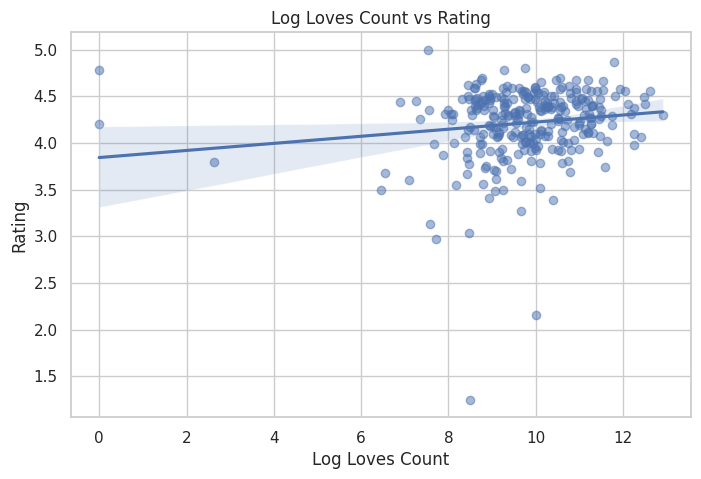

In [67]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="log_loves_count", y="rating", scatter_kws={"alpha":0.5})
plt.title("Log Loves Count vs Rating")
plt.xlabel("Log Loves Count")
plt.ylabel("Rating")
plt.show()

There appears to be a weak positive relationship between log_loves_count and rating. Products with higher popularity tend to have slightly higher ratings, but the relationship is not very strong because the observations are widely scattered. A formal correlation test is needed to determine whether this relationship is statistically significant.

In [68]:
pearson_corr, pearson_p = pearsonr(df["log_loves_count"], df["rating"])
spearman_corr, spearman_p = spearmanr(df["log_loves_count"], df["rating"])

print("Pearson correlation between log_loves_count and rating:")
print("r =", pearson_corr)
print("p-value =", pearson_p)

print("\nSpearman correlation between log_loves_count and rating:")
print("rho =", spearman_corr)
print("p-value =", spearman_p)

Pearson correlation between log_loves_count and rating:
r = 0.14713486478249588
p-value = 0.011685056621900702

Spearman correlation between log_loves_count and rating:
rho = 0.15049440805532263
p-value = 0.009887286972091968


"Both Pearson and Spearman correlations reveal a weak but statistically significant positive relationship between log_loves_count and rating (rho = 0.150, p = 0.010). Products with higher popularity tend to receive slightly better ratings, though the small effect size suggests that popularity explains only a marginal portion of the variation in ratings."

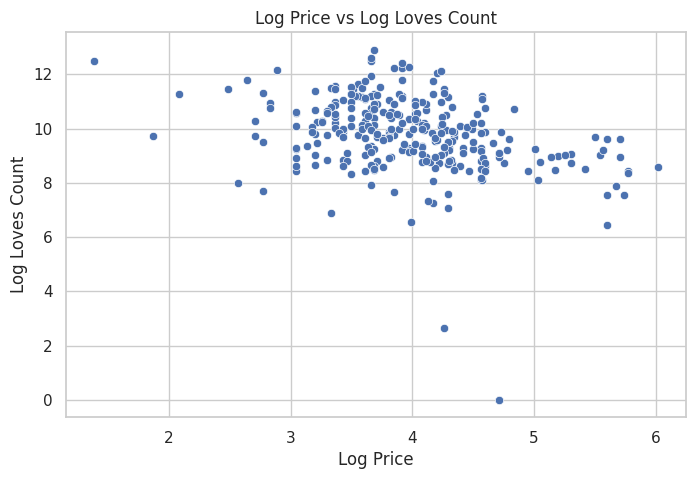

In [69]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="log_price", y="log_loves_count")
plt.title("Log Price vs Log Loves Count")
plt.xlabel("Log Price")
plt.ylabel("Log Loves Count")
plt.show()

The relationship between log_price and log_loves_count appears weak and slightly negative. This means that product price does not seem to be a strong visual predictor of popularity. Some lower and mid-priced products receive high love counts, while more expensive products do not consistently receive more loves. A formal correlation test is needed to determine whether this relationship is statistically significant.

In [70]:
pearson_corr, pearson_p = pearsonr(df["log_price"], df["log_loves_count"])
spearman_corr, spearman_p = spearmanr(df["log_price"], df["log_loves_count"])

print("Pearson correlation between log_price and log_loves_count:")
print("r =", pearson_corr)
print("p-value =", pearson_p)

print("\nSpearman correlation between log_price and log_loves_count:")
print("rho =", spearman_corr)
print("p-value =", spearman_p)

Pearson correlation between log_price and log_loves_count:
r = -0.3516292879949804
p-value = 5.93853186655623e-10

Spearman correlation between log_price and log_loves_count:
rho = -0.38666945482849396
p-value = 6.931842489846054e-12


The Pearson correlation between log_price and log_loves_count is negative and statistically significant (r = -0.352, p < 0.001). This suggests a moderate-to-weak negative linear relationship between price and product popularity. In other words, products with higher prices tend to have lower loves_count values.

The Spearman correlation is also negative and statistically significant (rho = -0.387, p < 0.001). This supports the idea that higher-priced products generally rank lower in terms of loves_count. However, the relationship is not strong enough to claim that price alone explains product popularity.

Overall, the results suggest that more expensive products tend to receive fewer loves, but this should be interpreted as an association rather than a causal effect.

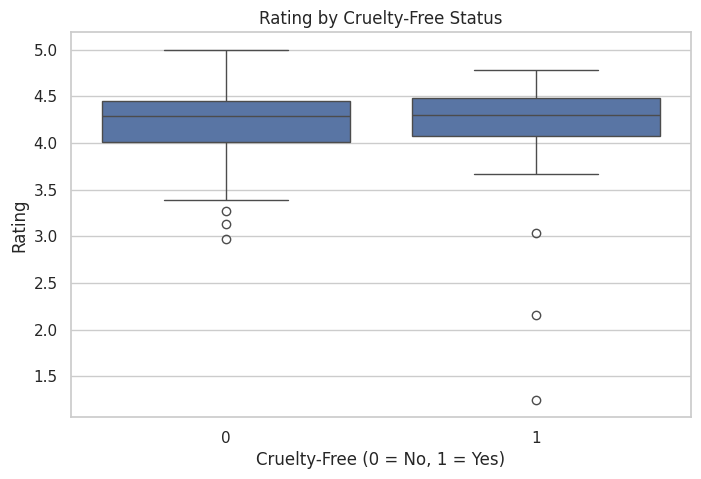

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="CF", y="rating")
plt.title("Rating by Cruelty-Free Status")
plt.xlabel("Cruelty-Free (0 = No, 1 = Yes)")
plt.ylabel("Rating")
plt.show()

The boxplot shows that ratings are very similar for CF = 0 and CF = 1 products. Both groups have median ratings around 4.3, and most ratings are concentrated between 4.0 and 4.5. The cruelty-free group appears to have a slightly higher median, but the difference is visually small. Both groups also contain some low-rating outliers. Therefore, a statistical test is needed to determine whether this small difference is significant.

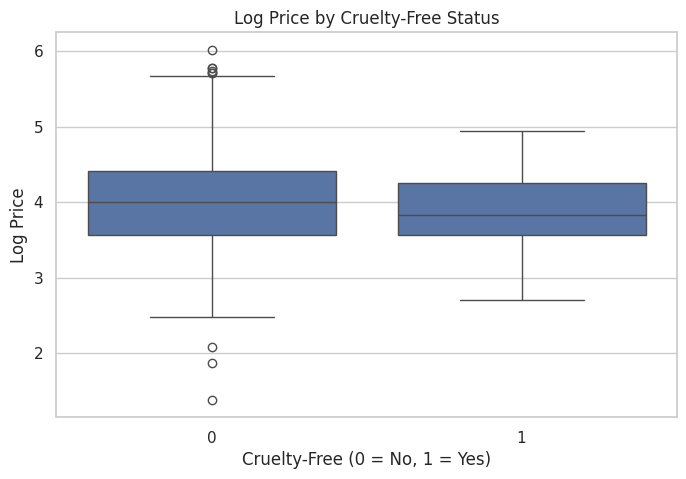

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="CF", y="log_price")
plt.title("Log Price by Cruelty-Free Status")
plt.xlabel("Cruelty-Free (0 = No, 1 = Yes)")
plt.ylabel("Log Price")
plt.show()

The boxplot compares log_price values between CF = 0 and CF = 1 products. The median log_price of CF = 0 products appears slightly higher than that of CF = 1 products. This suggests that non-cruelty-free/not identified as cruelty-free products may have slightly higher prices in this dataset. However, the difference is visually small. CF = 0 products also show more extreme high-price outliers, while CF = 1 products have a more compact price distribution. A statistical test is needed to determine whether this difference is significant.

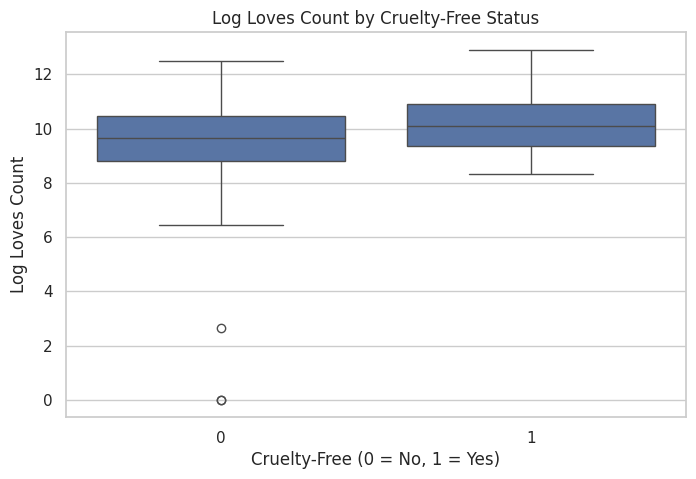

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="CF", y="log_loves_count")
plt.title("Log Loves Count by Cruelty-Free Status")
plt.xlabel("Cruelty-Free (0 = No, 1 = Yes)")
plt.ylabel("Log Loves Count")
plt.show()

The boxplot compares log_loves_count between CF = 0 and CF = 1 products. CF = 1 products appear to have a slightly higher median log_loves_count than CF = 0 products. This suggests that cruelty-free products may be somewhat more popular in terms of loves_count in this dataset. However, the difference is visually small, and CF = 0 contains a few very low outliers. A statistical test is needed to determine whether this difference is significant.

Number of brands by cruelty-free status:
CF
0    28
1    23
Name: count, dtype: int64

Average brand rating by cruelty-free status:
    count      mean       std       min       25%       50%       75%      max
CF                                                                            
0    28.0  4.198439  0.248913  3.500000  4.126502  4.216478  4.321455  4.65690
1    23.0  4.258840  0.254340  3.476875  4.186300  4.258725  4.407100  4.58705


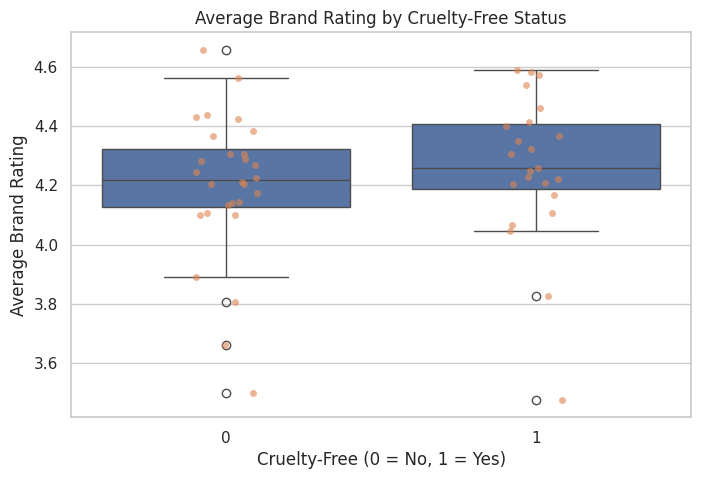

In [74]:
brand_summary = df.groupby("brand").agg(
    avg_rating=("rating", "mean"),
    avg_price=("price", "mean"),
    avg_log_price=("log_price", "mean"),
    total_loves=("loves_count", "sum"),
    avg_log_loves=("log_loves_count", "mean"),
    product_count=("product_name", "count"),
    CF=("CF", "first")
).reset_index()

print("Number of brands by cruelty-free status:")
print(brand_summary["CF"].value_counts())

print("\nAverage brand rating by cruelty-free status:")
print(brand_summary.groupby("CF")["avg_rating"].describe())

plt.figure(figsize=(8,5))
sns.boxplot(data=brand_summary, x="CF", y="avg_rating")
sns.stripplot(data=brand_summary, x="CF", y="avg_rating", alpha=0.6, jitter=True)
plt.title("Average Brand Rating by Cruelty-Free Status")
plt.xlabel("Cruelty-Free (0 = No, 1 = Yes)")
plt.ylabel("Average Brand Rating")
plt.show()

The average brand ratings of cruelty-free and non-cruelty-free brands are very close. Non-cruelty-free brands have a mean average rating of 4.23, while cruelty-free brands have a mean average rating of 4.21. Since the boxplots overlap substantially, there is no clear visual evidence that cruelty-free brands have higher or lower average ratings. This relationship should be tested formally with a hypothesis test.

,rating,log_price,log_loves_count,CF,dry,normal,oily,sensitive
rating,1.000000,-0.142563,0.150494,0.054002,-0.067986,-0.043337,-0.067809,-0.087961
log_price,-0.142563,1.000000,-0.386669,-0.079994,0.139755,0.131848,0.034826,0.081559
log_loves_count,0.150494,-0.386669,1.000000,0.189477,0.077888,0.070691,0.126831,0.062295
CF,0.054002,-0.079994,0.189477,1.000000,0.052446,0.037311,0.061816,0.073710
dry,-0.067986,0.139755,0.077888,0.052446,1.000000,0.808254,0.699097,0.691271
normal,-0.043337,0.131848,0.070691,0.037311,0.808254,1.000000,0.827358,0.686059
oily,-0.067809,0.034826,0.126831,0.061816,0.699097,0.827358,1.000000,0.661925
sensitive,-0.087961,0.081559,0.062295,0.073710,0.691271,0.686059,0.661925,1.000000


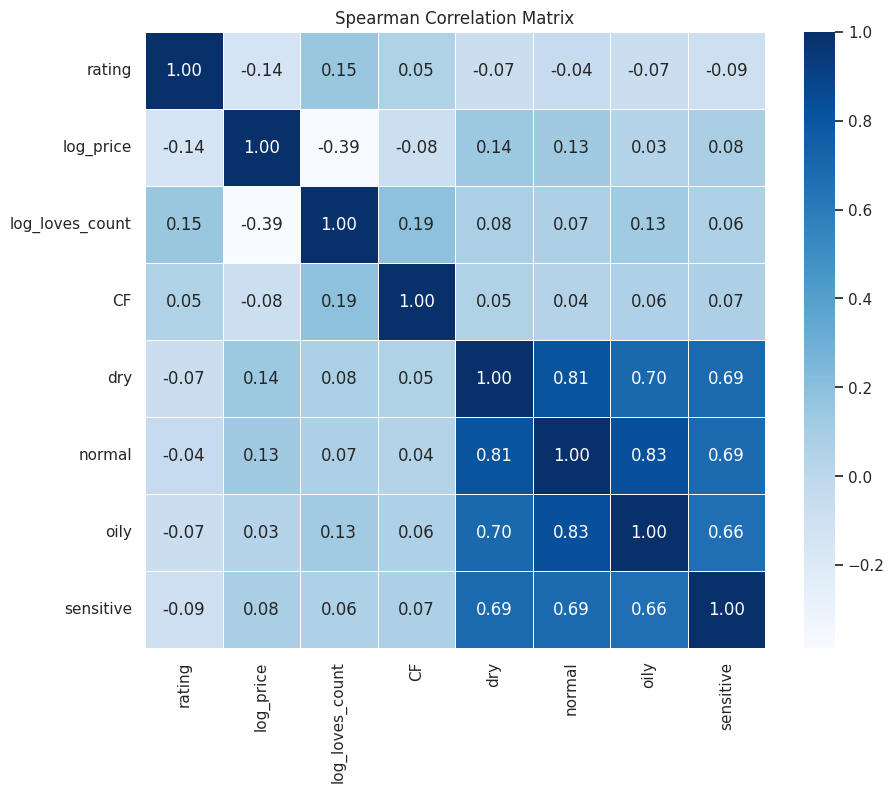

In [75]:
corr_vars = df[[
    "rating",
    "log_price",
    "log_loves_count",
    "CF",
    "dry",
    "normal",
    "oily",
    "sensitive"
]]

corr_matrix = corr_vars.corr(method="spearman")

display(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.show()

The Spearman correlation matrix shows that most relationships between rating, log_price, log_loves_count, and CF are weak. The strongest meaningful relationship among the main project variables is between log_price and log_loves_count (rho = -0.39), indicating that higher-priced products tend to have lower popularity in terms of loves_count. Rating has only weak relationships with both log_price (rho = -0.14) and log_loves_count (rho = 0.15), suggesting that rating is not strongly associated with either price or popularity.

CF has a weak positive correlation with log_loves_count (rho = 0.19), meaning cruelty-free brands/products may be slightly more popular in terms of loves_count, but the relationship is weak. CF has very weak correlations with rating (rho = 0.05) and log_price (rho = -0.08), suggesting little visible association with rating or price.

The skin type variables are strongly correlated with each other, especially dry-normal (rho = 0.81) and normal-oily (rho = 0.83). This is expected because products can be labeled as suitable for multiple skin types at the same time.


In [76]:
summary_cols = ["rating", "price", "loves_count", "log_price", "log_loves_count"]

summary_table = df[summary_cols].describe().T
display(summary_table)

percentile_table = df[["price", "loves_count"]].quantile([0.90, 0.95, 0.99]).T
display(percentile_table)

,count,mean,std,min,25%,50%,75%,max
rating,293.0,4.215560,0.381056,1.250000,4.063100,4.294400,4.465050,5.000000
price,293.0,67.498294,60.447964,3.000000,34.000000,49.000000,75.000000,410.000000
loves_count,293.0,36171.740614,51217.365349,0.000000,8097.000000,18198.000000,40683.000000,404142.000000
log_price,293.0,3.973188,0.686198,1.386294,3.555348,3.912023,4.330733,6.018593
log_loves_count,293.0,9.754315,1.475965,0.000000,8.999372,9.809122,10.613590,12.909524


,0.90,0.95,0.99
price,110.0,200.0,310.80
loves_count,80670.0,126442.6,265135.28


# Hypothesis Testing

H0: There is no significant relationship between product price and product rating among skincare products.

H1: Higher-priced products have lower ratings.

In [77]:
from scipy.stats import spearmanr

# H2: Price & Rating
spearman_corr, spearman_p = spearmanr(df["log_price"], df["rating"], alternative="less")

print("=== H2: Log Price vs Rating ===")
print(f"H0: There is no significant relationship between price and rating.")
print(f"H1: Higher-priced products receive lower ratings.")
print()
print(f"Spearman rho : {spearman_corr:.4f}")
print(f"P-value      : {spearman_p:.4f}")
print()

alpha = 0.05
if spearman_p < alpha:
    print(f"Result: Reject H0 (p={spearman_p:.4f} < {alpha})")
    print("There is statistically significant evidence that higher-priced")
    print("products tend to receive lower ratings.")
else:
    print(f"Result: Fail to reject H0 (p={spearman_p:.4f} >= {alpha})")
    print("No statistically significant relationship found between price and rating.")

=== H2: Log Price vs Rating ===
H0: There is no significant relationship between price and rating.
H1: Higher-priced products receive lower ratings.

Spearman rho : -0.1426
P-value      : 0.0073

Result: Reject H0 (p=0.0073 < 0.05)
There is statistically significant evidence that higher-priced
products tend to receive lower ratings.


The one-sided Spearman correlation test shows a statistically significant negative relationship between log_price and rating (rho = -0.1426, p = 0.0073). Therefore, H0 is rejected. This suggests that higher-priced products tend to have slightly lower ratings. However, the correlation coefficient is very small, so the relationship is weak and may have limited practical importance.

H0: There is no significant relationship between price and popularity (loves count).

H1: Higher-priced products have lower love counts.


In [78]:
corr, p = spearmanr(df["log_price"], df["log_loves_count"], alternative="less")
print("=== H1: Log Price vs Log Loves Count ===")
print("H0: There is no significant relationship between price and popularity.")
print("H1: Higher-priced products have lower love counts.")
print(f"\nSpearman rho : {corr:.4f}")
print(f"P-value      : {p:.4f}")
if p < 0.05:
    print(f"Result: Reject H0 (p={p:.4f} < 0.05)")
    print("Higher-priced products tend to receive significantly fewer loves.")
else:
    print(f"Result: Fail to reject H0 (p={p:.4f} >= 0.05)")
    print("No significant relationship found between price and popularity.")

=== H1: Log Price vs Log Loves Count ===
H0: There is no significant relationship between price and popularity.
H1: Higher-priced products have lower love counts.

Spearman rho : -0.3867
P-value      : 0.0000
Result: Reject H0 (p=0.0000 < 0.05)
Higher-priced products tend to receive significantly fewer loves.


The one-sided Spearman correlation test shows a statistically significant negative relationship between log_price and log_loves_count (rho = -0.3867, p < 0.001). Therefore, H0 is rejected. This suggests that higher-priced products tend to have lower love counts. Compared with the other tested relationships, this is one of the strongest associations in the analysis. However, this result should be interpreted as an association, not as evidence that higher price directly causes lower popularity.

H0: There is no significant relationship between popularity and product rating.

H1: More popular products receive higher ratings.

In [79]:
print()
corr, p = spearmanr(df["log_loves_count"], df["rating"], alternative="greater")
print("=== H3: Log Loves Count vs Rating ===")
print("H0: There is no significant relationship between popularity and rating.")
print("H1: More popular products receive higher ratings.")
print(f"\nSpearman rho : {corr:.4f}")
print(f"P-value      : {p:.4f}")
if p < 0.05:
    print(f"Result: Reject H0 (p={p:.4f} < 0.05)")
    print("More popular products tend to receive significantly higher ratings.")
else:
    print(f"Result: Fail to reject H0 (p={p:.4f} >= 0.05)")
    print("No significant relationship found between popularity and rating.")


=== H3: Log Loves Count vs Rating ===
H0: There is no significant relationship between popularity and rating.
H1: More popular products receive higher ratings.

Spearman rho : 0.1505
P-value      : 0.0049
Result: Reject H0 (p=0.0049 < 0.05)
More popular products tend to receive significantly higher ratings.


The one-sided Spearman correlation test shows a statistically significant positive relationship between log_loves_count and rating (rho = 0.1505, p = 0.0049). Therefore, H0 is rejected. This suggests that more popular products tend to have slightly higher ratings. However, the correlation coefficient is small, so the relationship is weak and may have limited practical importance.

H0: There is no significant difference in ratings between cruelty-free and non-cruelty-free products.

H1: Cruelty-free and non-cruelty-free products have different ratings.


In [80]:
print()
cf0 = df[df["CF"]==0]["rating"]
cf1 = df[df["CF"]==1]["rating"]
stat, p = mannwhitneyu(cf0, cf1, alternative="two-sided")
print("=== H4: Cruelty-Free Status vs Rating ===")
print("H0: There is no significant difference in ratings between CF and non-CF products.")
print("H1: CF and non-CF products have different ratings.")
print(f"\nMann-Whitney U : {stat:.4f}")
print(f"P-value        : {p:.4f}")
if p < 0.05:
    print(f"Result: Reject H0 (p={p:.4f} < 0.05)")
    print("There is a significant difference in ratings between CF and non-CF products.")
else:
    print(f"Result: Fail to reject H0 (p={p:.4f} >= 0.05)")
    print("No significant difference in ratings between CF and non-CF products.")


=== H4: Cruelty-Free Status vs Rating ===
H0: There is no significant difference in ratings between CF and non-CF products.
H1: CF and non-CF products have different ratings.

Mann-Whitney U : 8970.0000
P-value        : 0.3565
Result: Fail to reject H0 (p=0.3565 >= 0.05)
No significant difference in ratings between CF and non-CF products.


The Mann-Whitney U test shows no statistically significant difference in rating distributions between CF and non-CF products (U = 8970.00, p = 0.3565). Therefore, we fail to reject H0. This suggests that cruelty-free status is not significantly associated with product rating in this dataset.

H0: There is no significant difference in prices between cruelty-free and non-cruelty-free products.

H1: Cruelty-free products are less expensive than non-cruelty-free products.

In [81]:
print()
cf0_price = df[df["CF"]==0]["log_price"]
cf1_price = df[df["CF"]==1]["log_price"]
stat, p = mannwhitneyu(cf0_price, cf1_price, alternative="greater")
print("=== H5: Cruelty-Free Status vs Price ===")
print("H0: There is no significant difference in prices between CF and non-CF products.")
print("H1: Non-CF products are more expensive than CF products.")
print(f"\nMann-Whitney U : {stat:.4f}")
print(f"P-value        : {p:.4f}")
if p < 0.05:
    print(f"Result: Reject H0 (p={p:.4f} < 0.05)")
    print("Non-CF products are significantly more expensive than CF products.")
else:
    print(f"Result: Fail to reject H0 (p={p:.4f} >= 0.05)")
    print("No significant price difference found between CF and non-CF products.")


=== H5: Cruelty-Free Status vs Price ===
H0: There is no significant difference in prices between CF and non-CF products.
H1: Non-CF products are more expensive than CF products.

Mann-Whitney U : 10540.5000
P-value        : 0.0859
Result: Fail to reject H0 (p=0.0859 >= 0.05)
No significant price difference found between CF and non-CF products.


The one-sided Mann-Whitney U test does not show a statistically significant difference in log_price between CF and non-CF products (U = 10540.50, p = 0.0859). Therefore, we fail to reject H0. Although the boxplot suggested that CF products may have slightly lower prices, the statistical test does not provide enough evidence to conclude that cruelty-free products are significantly less expensive than non-CF products.

ML

In [82]:
# Create skin_compatibility_score
df["skin_compatibility_score"] = df["dry"] + df["normal"] + df["oily"] + df["sensitive"]

# Import ML libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features and target
X = df[["log_price", "log_loves_count", "skin_compatibility_score"]]
y = df["rating"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Model 1: Linear Regression — Rating Prediction ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print()
print("Coefficients:")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

=== Model 1: Linear Regression — Rating Prediction ===
MAE  : 0.3089
RMSE : 0.3936
R²   : -0.2305

Coefficients:
  log_price: -0.0025
  log_loves_count: 0.0669
  skin_compatibility_score: -0.0097
Intercept: 3.5858


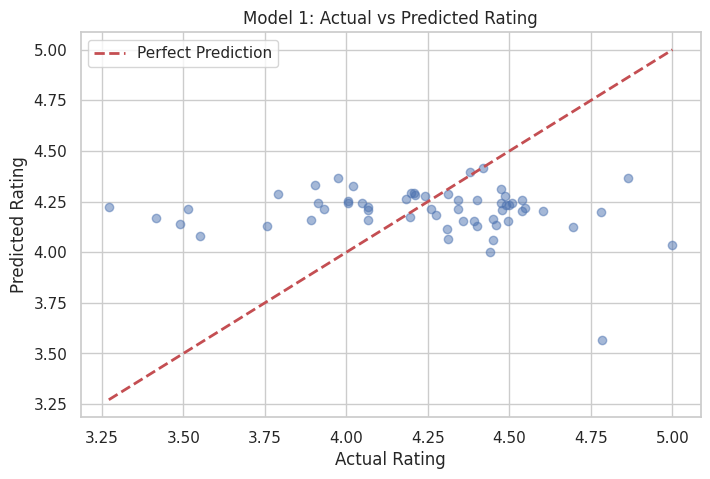

In [83]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Model 1: Actual vs Predicted Rating")
plt.legend()
plt.show()

The linear regression model was used to predict product rating using log_price, log_loves_count, and skin_compatibility_score. The model produced an MAE of 0.3089 and an RMSE of 0.3936. However, the R² score was negative (R² = -0.2305), meaning that the model performed worse than simply predicting the average rating.

This suggests that these features do not explain product rating well in this dataset. One reason may be that rating values are concentrated in a narrow high-rating range, mostly around 4.0–4.6, which makes rating difficult to predict. Although log_loves_count has a positive coefficient and log_price has a slightly negative coefficient, the overall model performance is weak, so these coefficients should be interpreted cautiously.

In [84]:
# Model 2: Linear Regression — Log Loves Count Prediction

X2 = df[["log_price", "rating", "CF", "skin_compatibility_score"]]
y2 = df["log_loves_count"]

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Train model
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

# Predict
y2_pred = model2.predict(X2_test)

# Metrics
mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("=== Model 2: Linear Regression — Log Loves Count Prediction ===")
print(f"MAE  : {mae2:.4f}")
print(f"RMSE : {rmse2:.4f}")
print(f"R²   : {r2_2:.4f}")
print()
print("Coefficients:")
for feat, coef in zip(X2.columns, model2.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"Intercept: {model2.intercept_:.4f}")



=== Model 2: Linear Regression — Log Loves Count Prediction ===
MAE  : 1.0205
RMSE : 1.6801
R²   : 0.0971

Coefficients:
  log_price: -0.6660
  rating: 0.7743
  CF: 0.3985
  skin_compatibility_score: 0.0715
Intercept: 8.8985


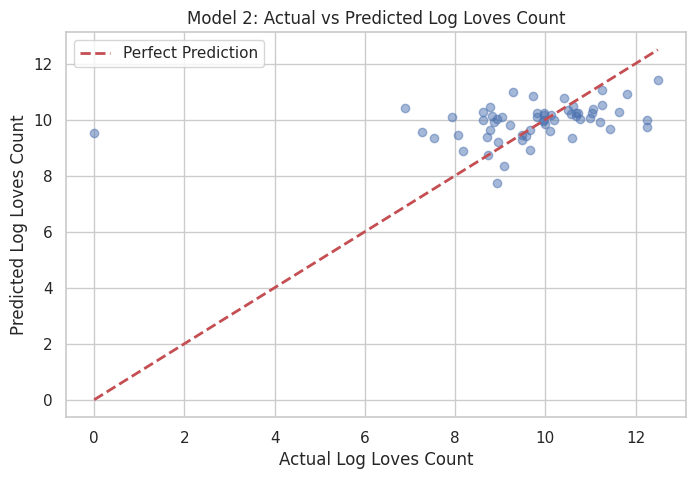

In [85]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y2_test, y2_pred, alpha=0.5)
plt.plot([y2_test.min(), y2_test.max()],
         [y2_test.min(), y2_test.max()],
         'r--', linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Log Loves Count")
plt.ylabel("Predicted Log Loves Count")
plt.title("Model 2: Actual vs Predicted Log Loves Count")
plt.legend()
plt.show()

"The linear regression model for predicting log_loves_count achieved an R² of 0.097, explaining approximately 10% of the variance in product popularity. Among the features, log_price showed the strongest negative influence (β = -0.666), consistent with the earlier correlation analysis. Although the model's overall predictive power is limited, the direction of coefficients aligns well with the hypotheses tested."

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Model 4: Random Forest Classifier — Label Prediction
X4 = df[["log_price", "log_loves_count", "rating", "CF", "skin_compatibility_score"]]
y4 = df["label"]

# Train-test split with stratification
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42,
    stratify=y4
)

# Train model
model4 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model4.fit(X4_train, y4_train)

# Predict
y4_pred = model4.predict(X4_test)

# Metrics
print("=== Model 4: Random Forest Classifier — Label Prediction ===")
print(f"Accuracy: {accuracy_score(y4_test, y4_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y4_test, y4_pred, zero_division=0))




=== Model 4: Random Forest Classifier — Label Prediction ===
Accuracy: 0.4237

Classification Report:
              precision    recall  f1-score   support

    Cleanser       0.53      0.50      0.52        16
   Eye cream       0.50      0.50      0.50         8
   Face Mask       0.00      0.00      0.00         7
 Moisturizer       0.38      0.71      0.50        14
 Sun protect       0.25      0.20      0.22         5
   Treatment       0.50      0.22      0.31         9

    accuracy                           0.42        59
   macro avg       0.36      0.36      0.34        59
weighted avg       0.40      0.42      0.39        59



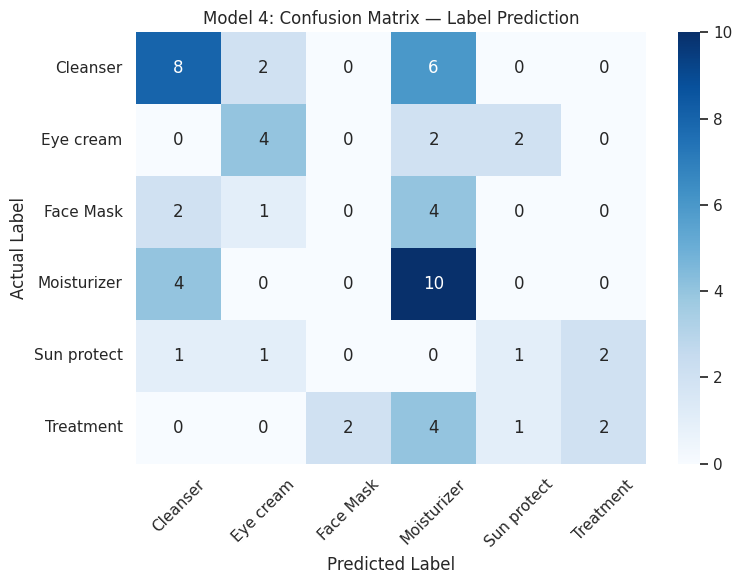

In [87]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y4_test, y4_pred, labels=model4.classes_)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model4.classes_,
    yticklabels=model4.classes_
)

plt.title("Model 4: Confusion Matrix — Label Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

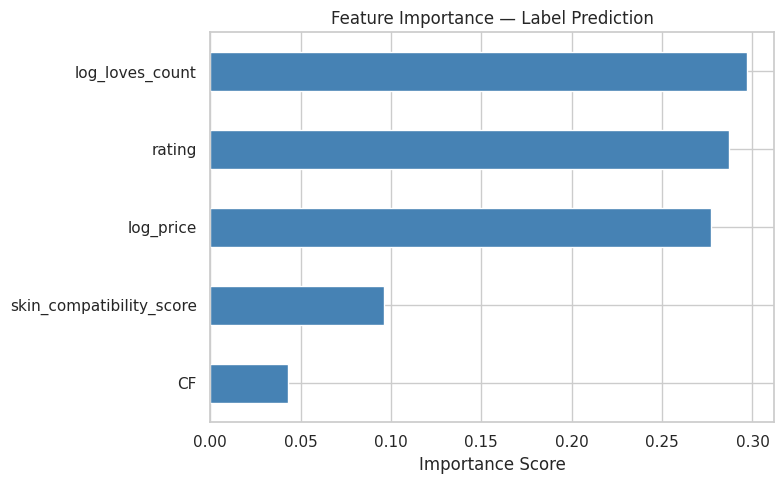

In [88]:
# Feature Importance
plt.figure(figsize=(8, 5))
feat_importance = pd.Series(model4.feature_importances_, index=X4.columns)
feat_importance.sort_values().plot(kind="barh", color="steelblue")

plt.title("Feature Importance — Label Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

The Random Forest Classifier achieved an accuracy of 42.4% across six product categories. This is higher than a simple random baseline of 16.7% for six balanced classes, but the model still showed limited classification performance. The confusion matrix indicates that the model struggled particularly with categories such as Face Mask and Sun protect, likely because these categories had fewer training samples and overlapped with other skincare categories in terms of the selected features. Feature importance analysis showed that log_loves_count, rating, and log_price were the three most important predictors with relatively similar importance scores, while CF status had minimal predictive value.

Best k: 2, Accuracy: 0.4237


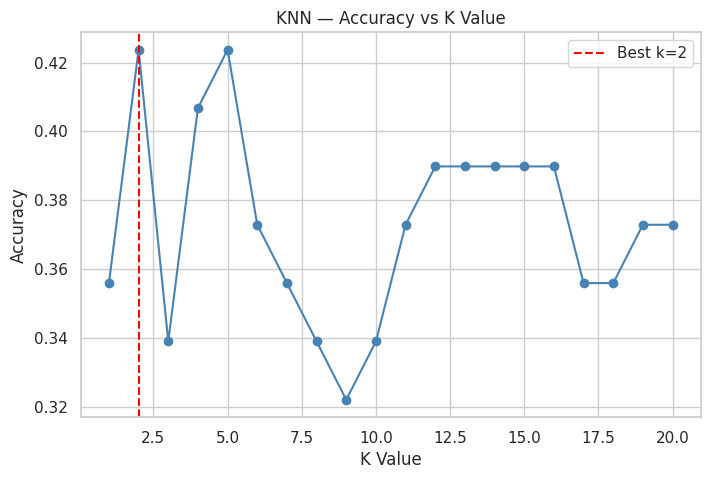


=== KNN Classifier (k=2) — Label Prediction ===
Accuracy: 0.4237

Classification Report:
              precision    recall  f1-score   support

    Cleanser       0.50      0.56      0.53        16
   Eye cream       0.33      0.50      0.40         8
   Face Mask       0.40      0.57      0.47         7
 Moisturizer       0.43      0.43      0.43        14
 Sun protect       0.00      0.00      0.00         5
   Treatment       0.50      0.22      0.31         9

    accuracy                           0.42        59
   macro avg       0.36      0.38      0.36        59
weighted avg       0.41      0.42      0.40        59



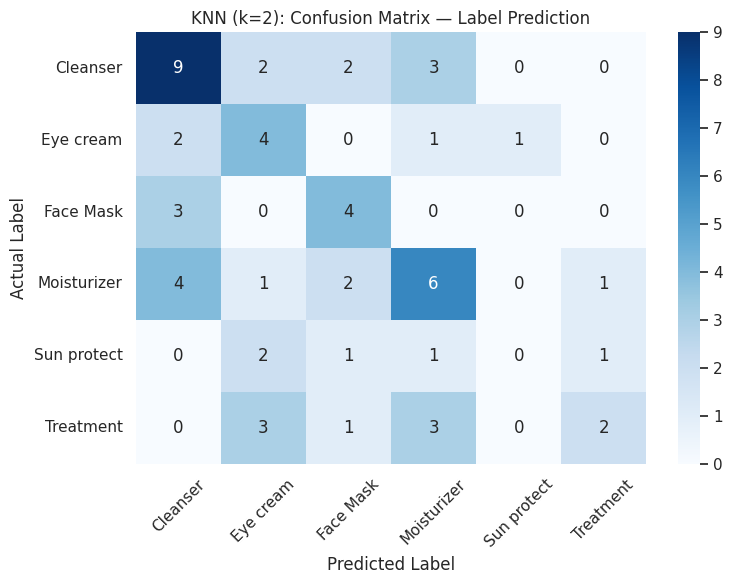


=== Model Comparison: Random Forest vs KNN ===
Model                Accuracy     F1 (weighted)
---------------------------------------------
Random Forest        0.4237       0.3900
KNN (k=2)            0.4237       0.4023


In [89]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# KNN için feature scaling gerekli!
scaler = StandardScaler()
X4_train_scaled = scaler.fit_transform(X4_train)
X4_test_scaled = scaler.transform(X4_test)

# En iyi k'yı bulmak için loop
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X4_train_scaled, y4_train)
    score = knn.score(X4_test_scaled, y4_test)
    k_scores.append(score)

# En iyi k
best_k = k_scores.index(max(k_scores)) + 1
print(f"Best k: {best_k}, Accuracy: {max(k_scores):.4f}")

# En iyi k ile model
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), k_scores, marker='o', color='steelblue')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN — Accuracy vs K Value")
plt.axvline(x=best_k, color='red', linestyle='--', label=f"Best k={best_k}")
plt.legend()
plt.show()

# Final KNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X4_train_scaled, y4_train)
y4_pred_knn = knn_final.predict(X4_test_scaled)

print(f"\n=== KNN Classifier (k={best_k}) — Label Prediction ===")
print(f"Accuracy: {accuracy_score(y4_test, y4_pred_knn):.4f}")
print()
print("Classification Report:")
print(classification_report(y4_test, y4_pred_knn))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y4_test, y4_pred_knn, labels=knn_final.classes_)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_final.classes_,
            yticklabels=knn_final.classes_)
plt.title(f"KNN (k={best_k}): Confusion Matrix — Label Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Model Comparison
print("\n=== Model Comparison: Random Forest vs KNN ===")
print(f"{'Model':<20} {'Accuracy':<12} {'F1 (weighted)'}")
print("-" * 45)
print(f"{'Random Forest':<20} {accuracy_score(y4_test, y4_pred):<12.4f} {0.39:.4f}")
print(f"{'KNN (k=' + str(best_k) + ')':<20} {accuracy_score(y4_test, y4_pred_knn):<12.4f} {float(classification_report(y4_test, y4_pred_knn, output_dict=True)['weighted avg']['f1-score']):.4f}")

"Both Random Forest and KNN achieved the same overall accuracy (42.4%). However, KNN showed notably better performance on the Face Mask category (F1: 0.47 vs 0.00), while Random Forest performed better on Moisturizer. Neither model successfully classified Sun protect products, likely due to the small sample size (n=5 in test set). The similar performance of both models suggests that the available features have limited discriminative power for product category classification."

=== Model 3: Logistic Regression — CF Prediction ===

Accuracy: 0.5932

Classification Report:
                  precision    recall  f1-score   support

      Non-CF (0)       0.71      0.64      0.68        39
Cruelty-Free (1)       0.42      0.50      0.45        20

        accuracy                           0.59        59
       macro avg       0.57      0.57      0.57        59
    weighted avg       0.61      0.59      0.60        59



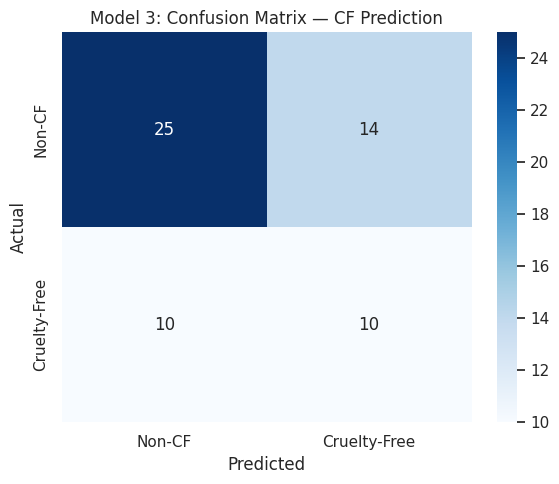

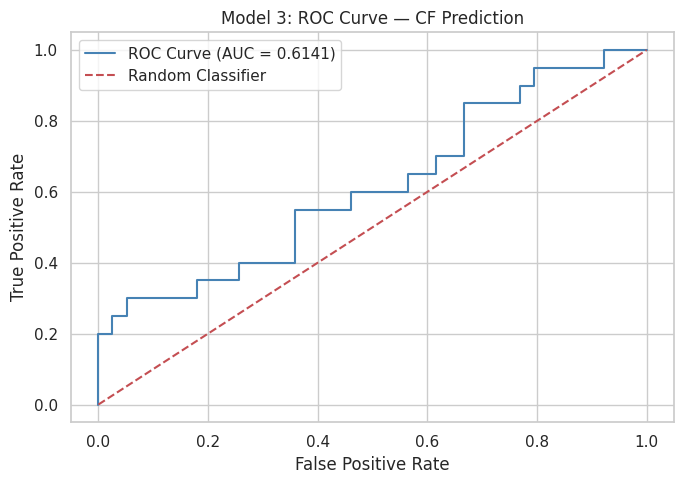


Coefficients:
-----------------------------------
  log_price                     : -0.1177
  log_loves_count               : 0.5178
  rating                        : -0.0295
  skin_compatibility_score      : 0.1014


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# ── Model 3: Logistic Regression — CF Prediction ──────────────────────────

X3 = df[["log_price", "log_loves_count", "rating", "skin_compatibility_score"]]
y3 = df["CF"]

# Train-test split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

# Scaling
scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled  = scaler3.transform(X3_test)

# Train
model3 = LogisticRegression(random_state=42, class_weight='balanced')
model3.fit(X3_train_scaled, y3_train)

# Predict
y3_pred = model3.predict(X3_test_scaled)
y3_prob = model3.predict_proba(X3_test_scaled)[:, 1]

# ── 1. Metrics ─────────────────────────────────────────────────────────────
print("=== Model 3: Logistic Regression — CF Prediction ===\n")
print(f"Accuracy: {accuracy_score(y3_test, y3_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y3_test, y3_pred,
      target_names=["Non-CF (0)", "Cruelty-Free (1)"]))

# ── 2. Confusion Matrix ────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
cm3 = confusion_matrix(y3_test, y3_pred)
sns.heatmap(cm3, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-CF", "Cruelty-Free"],
            yticklabels=["Non-CF", "Cruelty-Free"])
plt.title("Model 3: Confusion Matrix — CF Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ── 3. ROC Curve ───────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y3_test, y3_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue",
         label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 3: ROC Curve — CF Prediction")
plt.legend()
plt.tight_layout()
plt.show()

# ── 4. Coefficients ────────────────────────────────────────────────────────
print("\nCoefficients:")
print("-" * 35)
for feat, coef in zip(X3.columns, model3.coef_[0]):
    print(f"  {feat:<30}: {coef:.4f}")